<a href="https://colab.research.google.com/github/Bhuvana908/SkillStride-AI/blob/master/colab%20notebook/skill_gap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub sentence-transformers scikit-learn pandas numpy matplotlib -q

In [ ]:
import os, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')

In [ ]:
path = kagglehub.dataset_download("emaadakhter/jobs-and-skills-mapping-for-career-analysis")

print(f"✅ Path: {path}")
for f in os.listdir(path):
    print(f"   • {f}  ({os.path.getsize(os.path.join(path, f))/1024:.1f} KB)")

Using Colab cache for faster access to the 'jobs-and-skills-mapping-for-career-analysis' dataset.
✅ Path: /kaggle/input/jobs-and-skills-mapping-for-career-analysis
   • formatted_jobs.csv  (172.5 KB)


In [ ]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df_raw = pd.read_csv(os.path.join(path, csv_files[0]))

print(f"Shape   : {df_raw.shape}")
print(f"Columns : {list(df_raw.columns)}")
print(f"\nFirst 3 rows:")
display(df_raw.head(3))
print(f"\nNull values:\n{df_raw.isnull().sum()}")

Shape   : (970, 6)
Columns : ['ID_num', 'job_title', 'Short_description', 'Skills_required', 'Industry', 'Pay_grade']

First 3 rows:


,ID_num,job_title,Short_description,Skills_required,Industry,Pay_grade
0,1,Software Engineer,Develop and maintain web applications using modern frameworks,Problem Solving Logical Reasoning Attention to Detail Team Collaboration Critical Thinking,Technology,High paying
1,2,Data Scientist,Analyze large datasets to extract business insights and build predictive models,Analytical Thinking Pattern Recognition Mathematical Reasoning Problem Solving Research Skills,Technology,High paying
2,3,Marketing Manager,Lead marketing campaigns and brand strategy development,Creative Thinking Strategic Planning Communication Leadership Project Management,Marketing,Average paying



Null values:
ID_num               0
job_title            0
Short_description    0
Skills_required      0
Industry             0
Pay_grade            0
dtype: int64


In [ ]:
df = df_raw.copy()

# ── Correct column names (confirmed from diagnostic) ──────────────────────
job_col   = 'job_title'
skill_col = 'Skills_required'

print(f"Job column   → '{job_col}'")
print(f"Skill column → '{skill_col}'")

# ── Parse skills: space-separated multi-word skills ───────────────────────
# e.g. "Problem Solving Logical Reasoning Attention to Detail"
# These are PHRASE skills, not single words — we must split carefully

def parse_skills(val):
    """
    Skills are space-separated phrases like:
    'Problem Solving Logical Reasoning Attention to Detail'
    Known skill phrases in this dataset are typically 2-3 words.
    We split on known delimiters first, else treat whole string as one skill.
    """
    if not isinstance(val, str) or val.strip() in ['', 'nan', 'None']:
        return []

    val = val.strip()

    # If comma/pipe/semicolon separated — use those
    for sep in [',', '|', ';']:
        if sep in val:
            return [s.strip().lower() for s in val.split(sep) if s.strip()]

    # Skills in this dataset are known title-case phrases concatenated
    # Split on capital letters that start a new word group
    import re
    # Insert delimiter before each uppercase letter that follows a lowercase
    split_val = re.sub(r'(?<=[a-z])(?=[A-Z])', '|', val)
    if '|' in split_val:
        return [s.strip().lower() for s in split_val.split('|') if s.strip()]

    # Fallback: return whole string as one skill
    return [val.lower()]

df['skills_list'] = df[skill_col].apply(parse_skills)
df['job_clean']   = df[job_col].astype(str).str.strip().str.title()

# Drop nulls
df = df[df['skills_list'].apply(len) > 0]
df = df[df['job_clean'].str.len() > 0].reset_index(drop=True)

print(f"\nTotal rows after cleaning : {len(df)}")

# ── Preview parsed skills ──────────────────────────────────────────────────
print("\nSample parsed skills:")
for i in range(5):
    print(f"  Row {i}: {df['skills_list'].iloc[i]}")

# ── All unique skills in dataset ───────────────────────────────────────────
all_skills = [s for lst in df['skills_list'] for s in lst]
skill_freq = Counter(all_skills)
print(f"\nTotal unique skills : {len(skill_freq)}")
print(f"Top 20 skills:")
for skill, count in skill_freq.most_common(20):
    print(f"  {skill:<40} → {count} jobs")

Job column   → 'job_title'
Skill column → 'Skills_required'

Total rows after cleaning : 970

Sample parsed skills:
  Row 0: ['problem solving logical reasoning attention to detail team collaboration critical thinking']
  Row 1: ['analytical thinking pattern recognition mathematical reasoning problem solving research skills']
  Row 2: ['creative thinking strategic planning communication leadership project management']
  Row 3: ['creative problem solving empathy research skills visual thinking user-centered design']
  Row 4: ['analytical thinking attention to detail mathematical reasoning critical thinking report writing']

Total unique skills : 1120
Top 20 skills:
  communication                            → 304 jobs
  technology                               → 225 jobs
  analytics                                → 118 jobs
  reporting                                → 88 jobs
  attention to detail                      → 53 jobs
  leadership                               → 49 jobs
  orga

In [ ]:
# ── Group by job title: aggregate skills per role ─────────────────────────
def top_skills(lists, n=10):
    all_s = [s for lst in lists for s in lst]
    return [s for s, _ in Counter(all_s).most_common(n)]

df_jobs = (
    df.groupby('job_clean')['skills_list']
      .apply(top_skills)
      .reset_index()
      .rename(columns={'job_clean': 'Job Title', 'skills_list': 'Required Skills'})
)
df_jobs = df_jobs[df_jobs['Required Skills'].apply(len) >= 3].reset_index(drop=True)

print(f"Unique job roles  : {len(df_jobs)}")
print(f"Avg skills/role   : {df_jobs['Required Skills'].apply(len).mean():.1f}")
print(f"\nSample:")
for _, row in df_jobs.head(8).iterrows():
    print(f"  {row['Job Title']:<40} → {', '.join(row['Required Skills'])}")

Unique job roles  : 431
Avg skills/role   : 5.1

Sample:
  3D Printing Technician                   → 3d printing, cad, troubleshooting, material science, attention to detail
  Accounts Receivable Specialist           → accounts receivable, billing systems, customer service, attention to detail, communication
  Administrative Assistant                 → organization multitasking communication attention to detail discretion, office administration, calendar management, communication, microsoft office, organization
  Aerospace Engineer                       → aerodynamics, cad, materials science, systems engineering, testing
  Ai Chatbot Designer                      → conversation design, ai tools, ux, scripting, creativity
  Ai Data Labeling Supervisor              → team management, data annotation, quality control, communication, organization
  Ai Ethics Consultant                     → ethics, ai policy, communication, risk assessment, research
  Ai Model Validator                   

In [ ]:
print("🔧 Building training data...\n")

print(f"Pay grade distribution:")
print(df_raw['Pay_grade'].value_counts())
print(f"\nIndustry distribution:")
ind_counts = df_raw['Industry'].value_counts()
print(ind_counts.head(20))
print(f"\nTotal industries        : {len(ind_counts)}")
print(f"Industries with >= 10   : {(ind_counts >= 10).sum()}")
print(f"Industries with >= 20   : {(ind_counts >= 20).sum()}")

# ── MODEL A DATA: Pay Grade from Skills ───────────────────────────────────
df_ml = df.copy()
df_ml['pay_grade'] = df_raw.loc[df_ml.index, 'Pay_grade'].values
df_ml = df_ml[df_ml['pay_grade'].notna()].reset_index(drop=True)

mlb = MultiLabelBinarizer()
X   = mlb.fit_transform(df_ml['skills_list'])
le  = LabelEncoder()
y   = le.fit_transform(df_ml['pay_grade'])

print(f"\n✅ MODEL A — Pay Grade")
print(f"   Samples  : {X.shape[0]}")
print(f"   Features : {X.shape[1]}")
print(f"   Classes  : {le.classes_}")

# ── MODEL B DATA: Industry from Skills ────────────────────────────────────
# Only keep industries where count >= 20 (enough for train/test split)
min_ind_count = 20
valid_inds    = ind_counts[ind_counts >= min_ind_count].index
print(f"\n✅ MODEL B — Industry (keeping {len(valid_inds)} industries with >= {min_ind_count} samples)")
print(f"   Kept industries: {list(valid_inds)}")

df_ind           = df_ml.copy()
df_ind['industry'] = df_raw.loc[df_ml.index, 'Industry'].values
df_ind             = df_ind[df_ind['industry'].isin(valid_inds)].reset_index(drop=True)

# Refit MLB on industry subset
mlb_ind   = MultiLabelBinarizer()
X_ind     = mlb_ind.fit_transform(df_ind['skills_list'])
le_ind    = LabelEncoder()
y_ind     = le_ind.fit_transform(df_ind['industry'])

print(f"   Samples  : {X_ind.shape[0]}")
print(f"   Features : {X_ind.shape[1]}")
print(f"   Classes  : {len(le_ind.classes_)}")
print(f"   Class counts:")
for cls, cnt in zip(le_ind.classes_, np.bincount(y_ind)):
    print(f"      {cls:<30} → {cnt} samples")

# ── Embedding model for job matching ──────────────────────────────────────
print("\n⏳ Loading embedding model...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

df_jobs['Embedding'] = df_jobs['Required Skills'].apply(
    lambda s: embed_model.encode(', '.join(s))
)
job_embeddings = np.vstack(df_jobs['Embedding'].values)

print(f"✅ Job embeddings: {job_embeddings.shape}")
print(f"✅ All data ready!")

🔧 Building training data...

Pay grade distribution:
Pay_grade
Average paying    545
High paying       285
Low paying        140
Name: count, dtype: int64

Industry distribution:
Industry
Technology                197
Marketing                  94
Healthcare                 56
Education                  36
Human Resources            35
Environmental Services     30
Business Services          27
Science & Research         24
Finance                    24
Agriculture                22
Executive Leadership       20
Legal Services             18
Media & Publishing         16
Food Service               15
Manufacturing              13
Entertainment              13
Sales                      13
Construction               12
Food Production            12
Wellness                   12
Name: count, dtype: int64

Total industries        : 105
Industries with >= 10   : 21
Industries with >= 20   : 11

✅ MODEL A — Pay Grade
   Samples  : 970
   Features : 1120
   Classes  : ['Average paying' 'High

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Job embeddings: (431, 384)
✅ All data ready!


In [ ]:
# ════════════════════════════════════════════════════════════
# MODEL A — Predict Pay Grade from Skills
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("MODEL A — Predicting Pay Grade from Skills")
print("=" * 60)

X_train_pg, X_test_pg, y_train_pg, y_test_pg = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train_pg.shape[0]}  |  Test: {X_test_pg.shape[0]}\n")

models_def = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'LinearSVC'          : LinearSVC(max_iter=3000, C=1.0),
}

def train_and_eval(models_dict, X_tr, X_te, y_tr, y_te, label_encoder):
    results = {}
    print(f"  {'Model':<25} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>13}")
    print("  " + "─" * 60)
    for name, clf in models_dict.items():
        clf.fit(X_tr, y_tr)
        y_pred  = clf.predict(X_te)
        acc     = accuracy_score(y_te, y_pred)
        f1_mac  = f1_score(y_te, y_pred, average='macro',    zero_division=0)
        f1_w    = f1_score(y_te, y_pred, average='weighted', zero_division=0)
        results[name] = {
            'model': clf, 'accuracy': acc,
            'f1_macro': f1_mac, 'f1_weighted': f1_w,
            'y_pred': y_pred
        }
        print(f"  {name:<25} {acc*100:>9.2f}%  {f1_mac*100:>9.2f}%  {f1_w*100:>12.2f}%")

    best     = max(results, key=lambda k: results[k]['accuracy'])
    best_clf = results[best]['model']
    print(f"\n🏆 Best: {best}  ({results[best]['accuracy']*100:.2f}% accuracy)")
    print(f"\nClassification Report — {best}:")
    print(classification_report(
        y_te, results[best]['y_pred'],
        target_names=label_encoder.classes_, zero_division=0
    ))
    return results, best, best_clf

results_pg, best_pg, best_clf_pg = train_and_eval(
    {k: v for k, v in models_def.items()},   # fresh model instances
    X_train_pg, X_test_pg, y_train_pg, y_test_pg, le
)

# ════════════════════════════════════════════════════════════
# MODEL B — Predict Industry from Skills
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("MODEL B — Predicting Industry from Skills")
print("=" * 60)

# Verify every class has >= 2 samples before splitting
class_counts = np.bincount(y_ind)
min_count    = class_counts.min()
print(f"Min samples in any class : {min_count}")

if min_count < 2:
    # Drop classes with only 1 sample
    valid_cls  = np.where(class_counts >= 2)[0]
    mask       = np.isin(y_ind, valid_cls)
    X_ind_safe = X_ind[mask]
    y_ind_safe = y_ind[mask]
    # Re-encode labels to be consecutive
    le_ind_safe = LabelEncoder()
    y_ind_safe  = le_ind_safe.fit_transform(
        le_ind.inverse_transform(y_ind_safe)
    )
    print(f"Dropped {(~mask).sum()} samples from single-sample classes")
    print(f"Remaining samples : {X_ind_safe.shape[0]}")
else:
    X_ind_safe  = X_ind
    y_ind_safe  = y_ind
    le_ind_safe = le_ind

X_train_in, X_test_in, y_train_in, y_test_in = train_test_split(
    X_ind_safe, y_ind_safe,
    test_size=0.2, random_state=42, stratify=y_ind_safe
)
print(f"Train: {X_train_in.shape[0]}  |  Test: {X_test_in.shape[0]}\n")

models_def2 = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'LinearSVC'          : LinearSVC(max_iter=3000, C=1.0),
}

results_in, best_in, best_clf_in = train_and_eval(
    models_def2,
    X_train_in, X_test_in, y_train_in, y_test_in, le_ind_safe
)

# Save for use in Cell 9
le_ind = le_ind_safe
print("\n✅ Both models trained successfully!")

MODEL A — Predicting Pay Grade from Skills
Train: 776  |  Test: 194

  Model                       Accuracy   F1 Macro   F1 Weighted
  ────────────────────────────────────────────────────────────
  Logistic Regression           68.56%      58.54%         63.95%
  Random Forest                 63.92%      49.02%         55.64%
  LinearSVC                     66.49%      57.76%         62.51%

🏆 Best: Logistic Regression  (68.56% accuracy)

Classification Report — Logistic Regression:
                precision    recall  f1-score   support

Average paying       0.65      0.97      0.78       109
   High paying       0.88      0.26      0.41        57
    Low paying       0.86      0.43      0.57        28

      accuracy                           0.69       194
     macro avg       0.80      0.55      0.59       194
  weighted avg       0.75      0.69      0.64       194


MODEL B — Predicting Industry from Skills
Min samples in any class : 20
Train: 452  |  Test: 113

  Model           

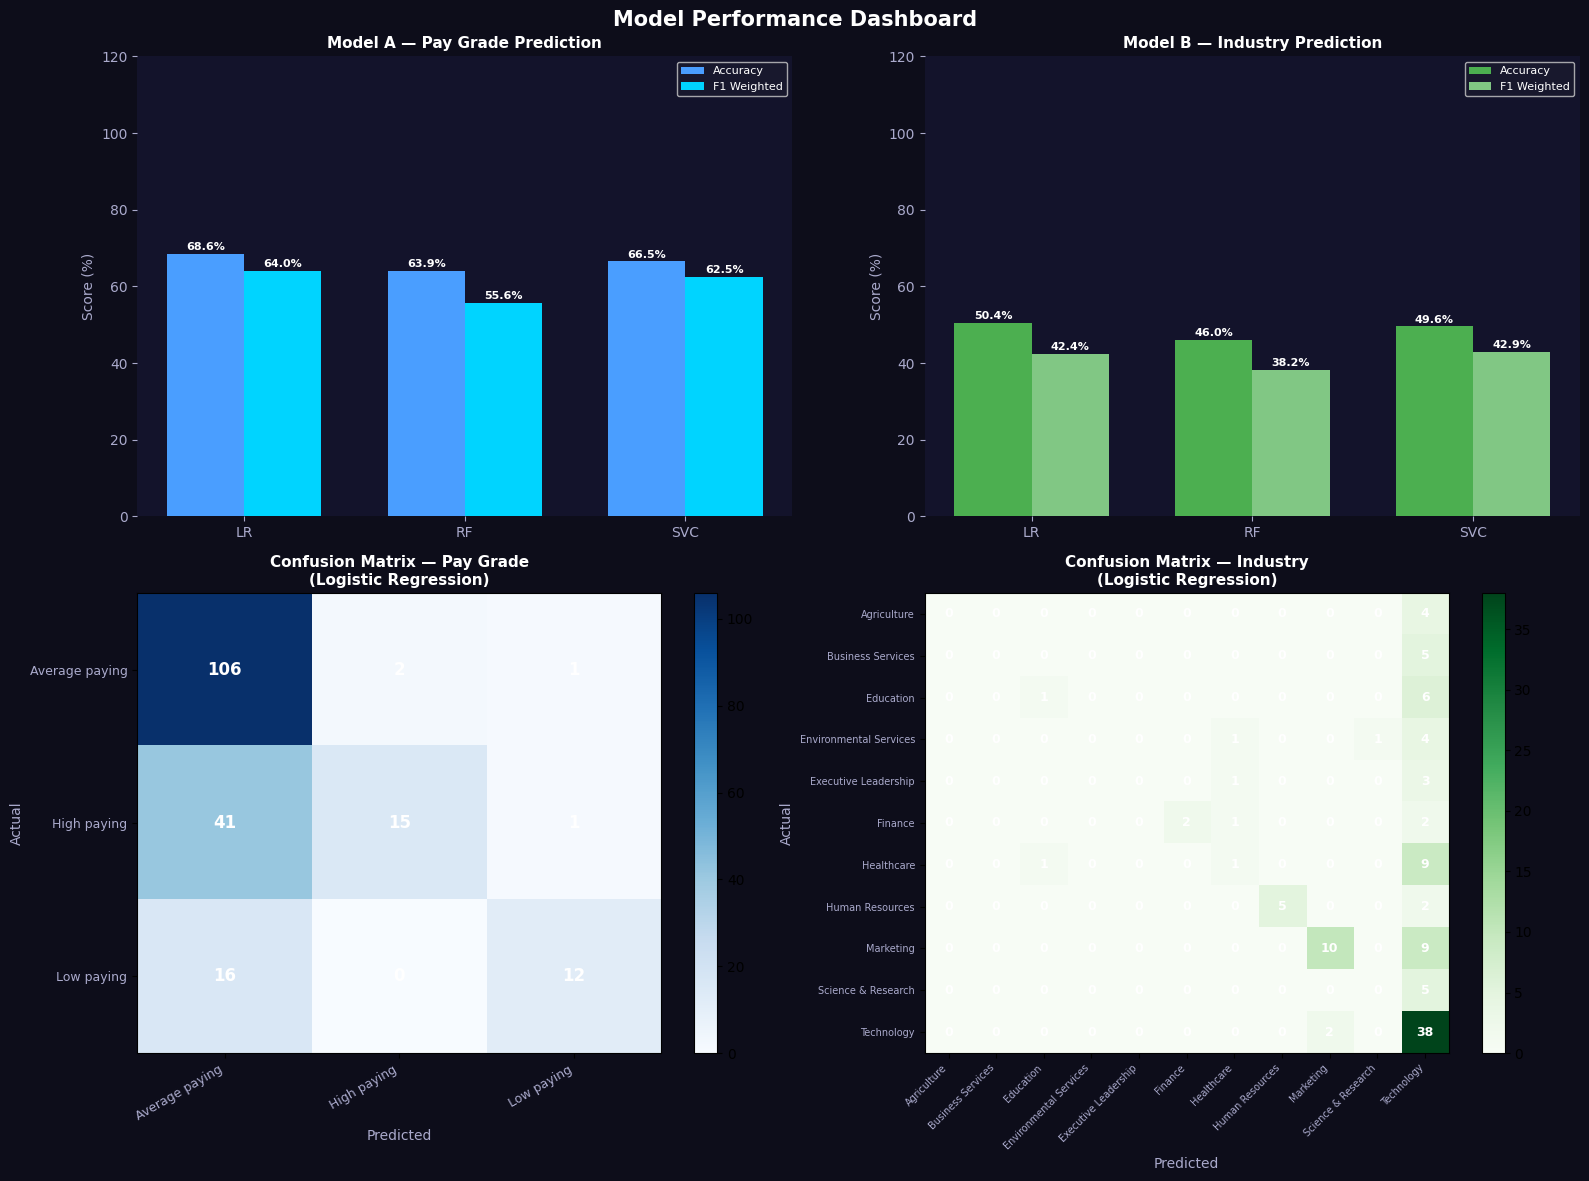


📊 FINAL MODEL SUMMARY
Task                           Best Model                  Accuracy
────────────────────────────────────────────────────────────
Pay Grade Prediction           Logistic Regression           68.56%
Industry Prediction            Logistic Regression           50.44%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0d0d1a')
fig.suptitle('Model Performance Dashboard', color='white', fontsize=15, fontweight='bold')

# ── Plot 1: Pay Grade — Accuracy & F1 comparison ─────────────────────────
ax1 = axes[0][0]
ax1.set_facecolor('#13132b')
names = list(results_pg.keys())
accs  = [results_pg[n]['accuracy'] * 100 for n in names]
f1s   = [results_pg[n]['f1_weighted'] * 100 for n in names]
x     = np.arange(len(names))
w     = 0.35
b1 = ax1.bar(x - w/2, accs, w, label='Accuracy',    color='#4a9eff', edgecolor='none')
b2 = ax1.bar(x + w/2, f1s,  w, label='F1 Weighted', color='#00d4ff', edgecolor='none')
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom',
             color='white', fontsize=8, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['LR', 'RF', 'SVC'], color='#aaaacc', fontsize=10)
ax1.set_title('Model A — Pay Grade Prediction', color='white', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score (%)', color='#aaaacc')
ax1.tick_params(colors='#aaaacc')
ax1.spines[:].set_visible(False)
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
ax1.set_ylim(0, 120)

# ── Plot 2: Industry — Accuracy & F1 comparison ───────────────────────────
ax2 = axes[0][1]
ax2.set_facecolor('#13132b')
names2 = list(results_in.keys())
accs2  = [results_in[n]['accuracy'] * 100 for n in names2]
f1s2   = [results_in[n]['f1_weighted'] * 100 for n in names2]
b3 = ax2.bar(x - w/2, accs2, w, label='Accuracy',    color='#4caf50', edgecolor='none')
b4 = ax2.bar(x + w/2, f1s2,  w, label='F1 Weighted', color='#81c784', edgecolor='none')
for bar in list(b3) + list(b4):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom',
             color='white', fontsize=8, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['LR', 'RF', 'SVC'], color='#aaaacc', fontsize=10)
ax2.set_title('Model B — Industry Prediction', color='white', fontsize=11, fontweight='bold')
ax2.set_ylabel('Score (%)', color='#aaaacc')
ax2.tick_params(colors='#aaaacc')
ax2.spines[:].set_visible(False)
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
ax2.set_ylim(0, 120)

# ── Plot 3: Confusion Matrix — Pay Grade ──────────────────────────────────
ax3 = axes[1][0]
ax3.set_facecolor('#13132b')
cm_pg = confusion_matrix(y_test_pg, results_pg[best_pg]['y_pred'])
im1   = ax3.imshow(cm_pg, cmap='Blues', aspect='auto')
ax3.set_xticks(range(len(le.classes_)))
ax3.set_yticks(range(len(le.classes_)))
ax3.set_xticklabels(le.classes_, rotation=30, ha='right', color='#aaaacc', fontsize=9)
ax3.set_yticklabels(le.classes_, color='#aaaacc', fontsize=9)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax3.text(j, i, str(cm_pg[i, j]), ha='center', va='center',
                 color='white', fontsize=12, fontweight='bold')
ax3.set_title(f'Confusion Matrix — Pay Grade\n({best_pg})',
              color='white', fontsize=11, fontweight='bold')
ax3.set_xlabel('Predicted', color='#aaaacc')
ax3.set_ylabel('Actual', color='#aaaacc')
plt.colorbar(im1, ax=ax3)

# ── Plot 4: Confusion Matrix — Industry ───────────────────────────────────
ax4 = axes[1][1]
ax4.set_facecolor('#13132b')
cm_in = confusion_matrix(y_test_in, results_in[best_in]['y_pred'])
im2   = ax4.imshow(cm_in, cmap='Greens', aspect='auto')
n_cls = len(le_ind.classes_)
ax4.set_xticks(range(n_cls))
ax4.set_yticks(range(n_cls))
ax4.set_xticklabels(le_ind.classes_, rotation=45, ha='right', color='#aaaacc', fontsize=7)
ax4.set_yticklabels(le_ind.classes_, color='#aaaacc', fontsize=7)
for i in range(n_cls):
    for j in range(n_cls):
        ax4.text(j, i, str(cm_in[i, j]), ha='center', va='center',
                 color='white', fontsize=9, fontweight='bold')
ax4.set_title(f'Confusion Matrix — Industry\n({best_in})',
              color='white', fontsize=11, fontweight='bold')
ax4.set_xlabel('Predicted', color='#aaaacc')
ax4.set_ylabel('Actual', color='#aaaacc')
plt.colorbar(im2, ax=ax4)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print("\n📊 FINAL MODEL SUMMARY")
print("=" * 60)
print(f"{'Task':<30} {'Best Model':<25} {'Accuracy':>10}")
print("─" * 60)
print(f"{'Pay Grade Prediction':<30} {best_pg:<25} {results_pg[best_pg]['accuracy']*100:>9.2f}%")
print(f"{'Industry Prediction':<30} {best_in:<25} {results_in[best_in]['accuracy']*100:>9.2f}%")
print("=" * 60)

In [ ]:
def predict_jobs(user_skills, top_n=5):
    """
    Find top N matching jobs using cosine similarity on embeddings.
    Also predicts pay grade + industry using trained ML models.
    """
    user_set       = set(s.lower().strip() for s in user_skills)
    user_embedding = embed_model.encode(', '.join(user_skills)).reshape(1, -1)
    similarities   = cosine_similarity(user_embedding, job_embeddings)[0]
    top_indices    = similarities.argsort()[::-1][:top_n]

    job_results = []
    for idx in top_indices:
        row         = df_jobs.iloc[idx]
        required    = list(row['Required Skills'])
        have        = sorted([s for s in required if s in user_set])
        missing     = sorted([s for s in required if s not in user_set])
        skill_match = round(len(have) / max(len(required), 1) * 100, 1)
        sem_score   = round(float(similarities[idx]) * 100, 1)
        job_results.append({
            'Job Title'       : row['Job Title'],
            'Similarity Score': sem_score,
            'Skill Match (%)'  : skill_match,
            'Skills You Have' : have,
            'Missing Skills'  : missing,
        })

    # ── ML predictions on user skill vector ───────────────────────────────
    # Pay grade prediction
    vec_pg = np.zeros(len(mlb.classes_), dtype=int)
    for i, skill in enumerate(mlb.classes_):
        if skill in user_set:
            vec_pg[i] = 1

    pay_pred  = best_clf_pg.predict(vec_pg.reshape(1, -1))[0]
    pay_label = le.inverse_transform([pay_pred])[0]

    # Industry prediction
    vec_in = np.zeros(len(mlb_ind.classes_), dtype=int)
    for i, skill in enumerate(mlb_ind.classes_):
        if skill in user_set:
            vec_in[i] = 1

    ind_pred  = best_clf_in.predict(vec_in.reshape(1, -1))[0]
    ind_label = le_ind.inverse_transform([ind_pred])[0]

    return pd.DataFrame(job_results), pay_label, ind_label


def skill_gap_for_job(user_skills, target_job):
    """
    Exact skill gap between user's skills and a specific target job.
    Returns matched, missing, bonus skills and readiness %.
    """
    user_set = set(s.lower().strip() for s in user_skills)

    # Exact title match first
    job_row = df_jobs[df_jobs['Job Title'].str.lower() == target_job.lower()]

    # Fuzzy: first word match
    if job_row.empty:
        kw      = target_job.lower().split()[0]
        job_row = df_jobs[df_jobs['Job Title'].str.lower().str.contains(kw, na=False)]

    if job_row.empty:
        return None

    job_row  = job_row.iloc[0]
    required = list(job_row['Required Skills'])
    req_set  = set(required)
    matched  = sorted(req_set & user_set)
    missing  = sorted(req_set - user_set)
    extra    = sorted(user_set - req_set)

    return {
        'Job Title'              : job_row['Job Title'],
        'Required Skills'        : required,
        'Skills You Have'        : matched,
        'Skills You Are Missing' : missing,
        'Bonus Skills'           : extra,
        'Readiness (%)'          : round(len(matched) / max(len(required), 1) * 100, 1),
    }


print("✅ predict_jobs()  and  skill_gap_for_job()  ready!")

✅ predict_jobs()  and  skill_gap_for_job()  ready!


In [ ]:
# Run this BEFORE Cell 11 to know what skills to enter
# Skills must match the dataset's Title Case phrase style

all_skills = sorted(set(
    s.title() for lst in df_jobs['Required Skills'] for s in lst
))

print(f"Total unique skills in dataset : {len(all_skills)}\n")
print("All available skills:")
print("─" * 50)
for i, s in enumerate(all_skills, 1):
    print(f"  {i:3}. {s}")

Total unique skills in dataset : 659

All available skills:
──────────────────────────────────────────────────
    1. 3D Printing
    2. A/B Testing
    3. Accessibility
    4. Accessibility Standards
    5. Accessibility Testing
    6. Account Management
    7. Accounting
    8. Accounting Software
    9. Accounting Standards
   10. Accounts Receivable
   11. Accuracy
   12. Active Listening
   13. Active Listening Patience Problem Solving Communication Empathy
   14. Administrative Support
   15. Administrative Tasks
   16. Adobe Creative Suite
   17. Adult Learning
   18. Advanced Analytics
   19. Advanced Programming
   20. Advanced Statistics
   21. Advertising
   22. Advocacy
   23. Aerodynamics
   24. Agile Development
   25. Agile Methodologies
   26. Agricultural Skills
   27. Agriculture
   28. Ai Policy
   29. Ai Strategy
   30. Ai Tools
   31. Analysis
   32. Analytical Skills
   33. Analytical Thinking
   34. Analytical Thinking Creative Problem Solving Data Interpretation

In [ ]:
import pickle

# ── Save everything needed for Streamlit ──────────────────────────────────
artifacts = {
    # ML Models
    'best_clf_pg'    : best_clf_pg,       # Pay grade classifier
    'best_clf_in'    : best_clf_in,       # Industry classifier

    # Encoders
    'mlb'            : mlb,               # MultiLabelBinarizer (pay grade)
    'mlb_ind'        : mlb_ind,           # MultiLabelBinarizer (industry)
    'le'             : le,                # LabelEncoder (pay grade)
    'le_ind'         : le_ind,            # LabelEncoder (industry)

    # Job data & embeddings
    'df_jobs'        : df_jobs,           # Job title → required skills
    'job_embeddings' : job_embeddings,    # Pre-computed embeddings

    # Metadata
    'all_skills'     : sorted(set(
                           s.title()
                           for lst in df_jobs['Required Skills']
                           for s in lst
                       )),
    'all_job_titles' : sorted(df_jobs['Job Title'].tolist()),
}

with open('skill_gap_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("✅ All artifacts saved to: skill_gap_artifacts.pkl")
print("\nSaved:")
for key in artifacts:
    print(f"   • {key}")

✅ All artifacts saved to: skill_gap_artifacts.pkl

Saved:
   • best_clf_pg
   • best_clf_in
   • mlb
   • mlb_ind
   • le
   • le_ind
   • df_jobs
   • job_embeddings
   • all_skills
   • all_job_titles
